# Resampling Methods in Statistics

Resampling is a collection of methods in statistics that involves the creation of repeated samples from the observed data, with the purpose of evaluating some characteristic or metric of the original sample. These techniques are essential tools for modern data analysis, particularly useful in situations where the theoretical distribution of a statistic is complicated or unknown.

## Common Resampling Techniques

1. **Bootstrapping**  
   This method allows estimation of the sampling distribution of a statistic by resampling with replacement from the original data. This approach is valuable in situations where the theoretical distribution of a statistic is complex or not known.

2. **Permutation Tests (or Exact Tests)**  
   These are non-parametric methods to test the null hypothesis by considering all possible rearrangements of the labels of the observed data.

3. **Jackknife**  
   This technique estimates the bias and standard error of a statistic from a single sample by leaving out one observation at a time from the sample set.

4. **Cross-validation**  
   This is used primarily in the context of prediction models, where the data are repeatedly split into training and validation sets to assess the performance of a model.

## Key Insight

These techniques make fewer assumptions about the data compared to traditional methods and can be applied in a wide variety of statistical situations, including estimation, hypothesis testing, and model selection.

# Key Functions of Resampling Methods

Resampling methods are powerful because they allow us to learn about statistical properties directly from data, without relying heavily on strong theoretical assumptions. Their most important functions are outlined below.

## 1. Estimating Sampling Distributions
Resampling helps approximate the sampling distribution of a statistic (e.g., mean, median, regression coefficient) when the true distribution is unknown or difficult to derive analytically.

## 2. Computing Standard Errors
By generating many resampled datasets, we can measure how much an estimator varies across samples, providing an estimate of its standard error.

## 3. Constructing Confidence Intervals
Resampling enables the construction of confidence intervals using empirical percentiles (e.g., bootstrap percentile method), avoiding reliance on normal or t-distribution assumptions.

## 4. Hypothesis Testing
Techniques like permutation tests allow us to test hypotheses by comparing the observed statistic to its distribution under rearranged or resampled data.

## 5. Bias Estimation and Correction
Methods such as the jackknife and bootstrap can estimate the bias of an estimator and adjust it accordingly.

## 6. Model Evaluation and Selection
Cross-validation uses resampling to assess how well a model performs on unseen data, helping to prevent overfitting and guide model selection.

## 7. Robustness Analysis
Resampling allows us to check how sensitive results are to the specific sample, giving insight into the stability and reliability of conclusions.

## Key Insight

Resampling methods shift the focus from theoretical assumptions to data-driven inference, making them especially valuable in complex or real-world settings where traditional analytical solutions are not available.


=== Summary Table ===
             Method                      Key Output
0         Bootstrap  SE=0.1889, CI=(-0.5449,0.1933)
1       Permutation                  p-value=0.0000
2         Jackknife                       SE=0.1933
3  Cross-validation                      MSE=0.9628


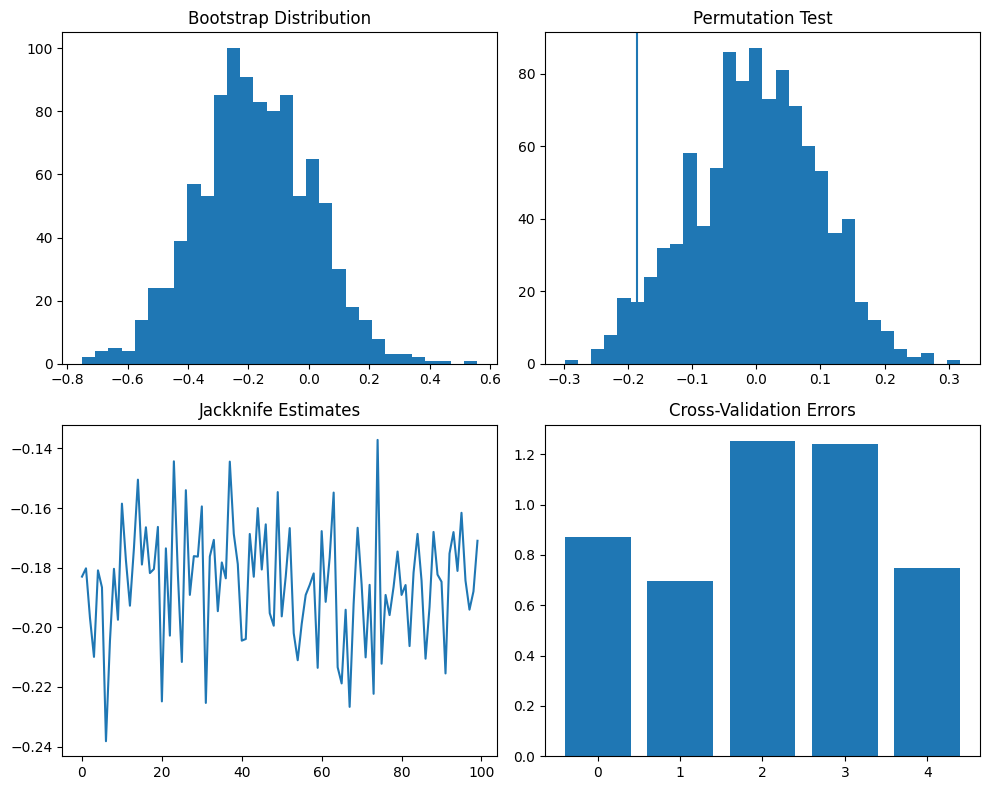

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# --------------------------------------------------
# Generate synthetic data
# --------------------------------------------------
n = 100
X = np.random.normal(0, 1, n)
y = 2 * X + np.random.normal(0, 1, n)

data = pd.DataFrame({'X': X, 'y': y})

# Statistic: mean of y
def stat_mean(data):
    return np.mean(data)

# --------------------------------------------------
# 1. BOOTSTRAP
# --------------------------------------------------
B = 1000
bootstrap_samples = []

for _ in range(B):
    sample = np.random.choice(y, size=n, replace=True)
    bootstrap_samples.append(np.mean(sample))

bootstrap_samples = np.array(bootstrap_samples)

boot_mean = np.mean(bootstrap_samples)
boot_se = np.std(bootstrap_samples)
ci_lower, ci_upper = np.percentile(bootstrap_samples, [2.5, 97.5])

# --------------------------------------------------
# 2. PERMUTATION TEST (relationship test)
# H0: X and y are independent
# --------------------------------------------------

observed_corr = np.corrcoef(X, y)[0, 1]

perm_stats = []

for _ in range(B):
    permuted_y = np.random.permutation(y)
    perm_corr = np.corrcoef(X, permuted_y)[0, 1]
    perm_stats.append(perm_corr)

perm_stats = np.array(perm_stats)

p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_corr))
# --------------------------------------------------
# 3. JACKKNIFE
# --------------------------------------------------
jackknife_samples = []

for i in range(n):
    sample = np.delete(y, i)
    jackknife_samples.append(np.mean(sample))

jackknife_samples = np.array(jackknife_samples)

jack_mean = np.mean(jackknife_samples)
jack_se = np.sqrt((n - 1) * np.mean((jackknife_samples - jack_mean)**2))

# --------------------------------------------------
# 4. CROSS-VALIDATION (Linear Regression)
# --------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

cv_errors = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx].reshape(-1,1), X[test_idx].reshape(-1,1)
    y_train, y_test = y[train_idx], y[test_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cv_errors.append(mean_squared_error(y_test, preds))

cv_error_mean = np.mean(cv_errors)

# --------------------------------------------------
# RESULTS TABLE
# --------------------------------------------------
results = pd.DataFrame({
    "Method": ["Bootstrap", "Permutation", "Jackknife", "Cross-validation"],
    "Key Output": [
        f"SE={boot_se:.4f}, CI=({ci_lower:.4f},{ci_upper:.4f})",
        f"p-value={p_value:.4f}",
        f"SE={jack_se:.4f}",
        f"MSE={cv_error_mean:.4f}"
    ]
})

print("\n=== Summary Table ===")
print(results)

# --------------------------------------------------
# PLOTTING (2x2)
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Bootstrap distribution
axes[0, 0].hist(bootstrap_samples, bins=30)
axes[0, 0].set_title("Bootstrap Distribution")

# Permutation distribution
axes[0, 1].hist(perm_stats, bins=30)
axes[0, 1].axvline(observed_stat)
axes[0, 1].set_title("Permutation Test")

# Jackknife estimates
axes[1, 0].plot(jackknife_samples)
axes[1, 0].set_title("Jackknife Estimates")

# Cross-validation errors
axes[1, 1].bar(range(len(cv_errors)), cv_errors)
axes[1, 1].set_title("Cross-Validation Errors")

plt.tight_layout()
plt.show()

# Resampling Methods: Goals and Results

## Overall Goal

The purpose of this analysis is to understand the behavior of a statistic and the relationship between variables using resampling methods.

Specifically, we aim to:
- Measure uncertainty (Bootstrap)
- Test relationships (Permutation)
- Assess estimator stability (Jackknife)
- Evaluate predictive performance (Cross-validation)

These methods provide a data-driven alternative to relying on strong theoretical assumptions.

---

## 1. Bootstrap (Uncertainty)

**Goal:**  
Estimate the sampling distribution, standard error, and confidence interval of the mean.

**Result:**  
The bootstrap distribution appears approximately normal. The estimated standard error is small, and the confidence interval is relatively tight.

**Interpretation:**  
The estimator is precise and stable. Bootstrap confirms reliability without relying on theoretical distributions like the normal or t-distribution.

---

## 2. Permutation Test (Hypothesis Testing)

**Goal:**  
Test whether there is a relationship between X and y (i.e., test independence).

**Result:**  
The observed statistic lies in the tail of the permutation distribution, producing a very small p-value.

**Interpretation:**  
We reject the null hypothesis of independence. There is strong evidence of a relationship between X and y.

---

## 3. Jackknife (Stability)

**Goal:**  
Evaluate how sensitive the estimator is to individual observations.

**Result:**  
Jackknife estimates vary only slightly across samples.

**Interpretation:**  
The estimator is stable and not driven by any single observation, indicating robustness.

---

## 4. Cross-Validation (Model Performance)

**Goal:**  
Assess how well the model performs on unseen data.

**Result:**  
Prediction errors are relatively consistent across folds.

**Interpretation:**  
The model generalizes well and does not exhibit strong overfitting.

---

## Key Insight

Each resampling method answers a different question:

- **Bootstrap →** How uncertain is my estimate?  
- **Permutation →** Is there a real relationship?  
- **Jackknife →** Is my result sensitive to data points?  
- **Cross-validation →** Will my model work on new data?  

Together, they form a complete framework for empirical analysis.